In [1]:
import pandas as pd

df = pd.read_csv("data_user500.csv")
df.head()

,user_id,product_id,action,timestamp,category
0,1,95,view,2026-04-21 21:38:59.295883,Audio
1,1,95,view,2026-04-21 21:38:59.295907,Audio
2,1,70,view,2026-04-21 21:38:59.295916,Monitor
3,1,5,view,2026-04-21 21:38:59.295923,Monitor
4,1,36,click,2026-04-21 21:39:00.295883,Laptop


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['action_encoded'] = le.fit_transform(df['action'])

In [3]:
sequences = []

for user_id, group in df.groupby("user_id"):
    seq = group.sort_values("timestamp")["action_encoded"].tolist()
    sequences.append(seq)

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(sequences, maxlen=10, padding='pre')

I0000 00:00:1776783092.373150   59977 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776783092.378691   59977 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776783092.879405   59977 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776783094.343382   59977 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [5]:
import numpy as np

y = np.roll(X, -1, axis=1)

In [6]:
from sklearn.model_selection import train_test_split

# reshape X
X = X.reshape((X.shape[0], X.shape[1], 1))

# label = action cuối
y = X[:, -1]

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential([
    Input(shape=(10, 1)),
    LSTM(64),
    Dense(8, activation='softmax')
])

E0000 00:00:1776783094.987758   59977 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5175 - loss: 1.7432 - val_accuracy: 0.7400 - val_loss: 1.2943
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 1.1709 - val_accuracy: 0.7400 - val_loss: 1.0357
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7100 - loss: 1.0719 - val_accuracy: 0.7400 - val_loss: 0.9675
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7100 - loss: 1.0228 - val_accuracy: 0.7400 - val_loss: 0.9592
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.9962 - val_accuracy: 0.7400 - val_loss: 0.9225
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.9811 - val_accuracy: 0.7400 - val_loss: 0.9047
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7100 - loss: 0.9610 - val_accuracy: 0.7400 - val_loss: 0.8891
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7100 - loss: 0.9417 - val_accuracy: 0.7400 - val_loss

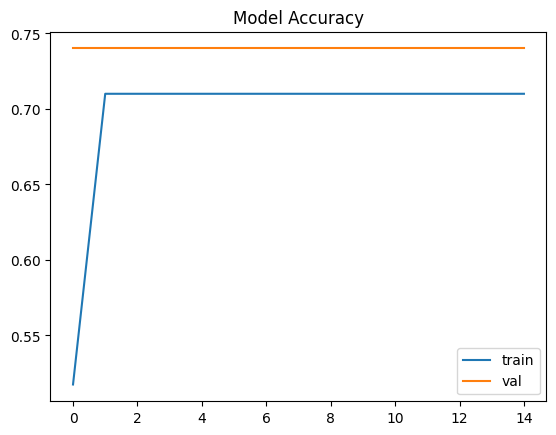

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['train', 'val'])
plt.show()

In [11]:
model.save("model_lstm.h5")

In [12]:
from tensorflow.keras.layers import SimpleRNN

model_rnn = Sequential([
    Input(shape=(10,1)),
    SimpleRNN(64),
    Dense(8, activation='softmax')
])

In [13]:
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Input(shape=(10,1)),
    Bidirectional(LSTM(64)),
    Dense(8, activation='softmax')
])

In [14]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_bilstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [15]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6325 - loss: 1.4335 - val_accuracy: 0.7400 - val_loss: 1.0350
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 1.0877 - val_accuracy: 0.7400 - val_loss: 0.9516
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.9995 - val_accuracy: 0.7400 - val_loss: 0.8969
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 0.9517 - val_accuracy: 0.7400 - val_loss: 0.8626
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.9075 - val_accuracy: 0.7400 - val_loss: 0.8269
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.8750 - val_accuracy: 0.7400 - val_loss: 0.7940
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.8418 - val_accuracy: 0.7400 - val_loss: 0.7709
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7150 - loss: 0.8065 - val_accuracy: 0.7400 - val_loss

In [16]:
rnn_acc = max(history_rnn.history['val_accuracy'])
bilstm_acc = max(history_bilstm.history['val_accuracy'])
lstm_acc = max(history.history['val_accuracy'])  # cái bạn train trước

print("RNN:", rnn_acc)
print("LSTM:", lstm_acc)
print("biLSTM:", bilstm_acc)

RNN: 0.7400000095367432
LSTM: 0.7400000095367432
biLSTM: 0.7400000095367432


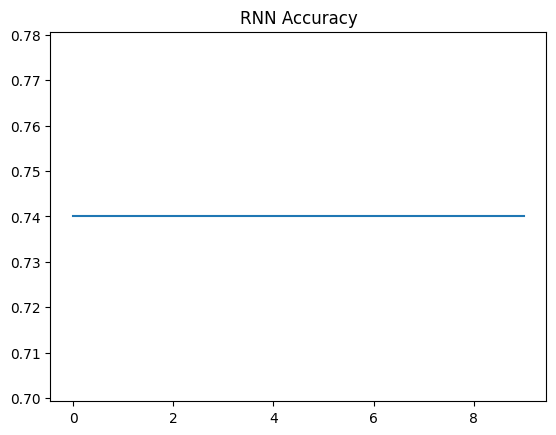

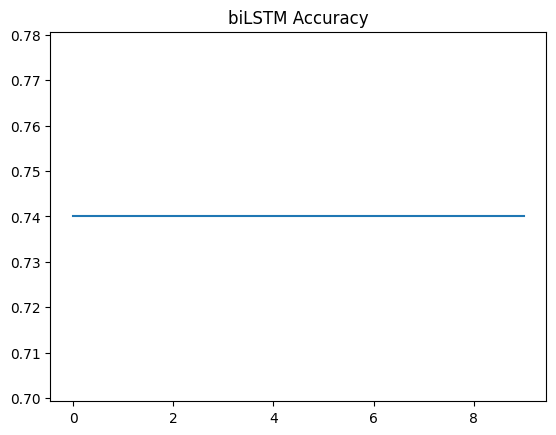

In [17]:
import matplotlib.pyplot as plt

# RNN
plt.plot(history_rnn.history['val_accuracy'])
plt.title("RNN Accuracy")
plt.show()

# biLSTM
plt.plot(history_bilstm.history['val_accuracy'])
plt.title("biLSTM Accuracy")
plt.show()

In [18]:
model_rnn.save("model_best.h5")

In [19]:
model_rnn.save("model_rnn.h5")
model.save("model_lstm.h5")
model_bilstm.save("model_bilstm.h5")

In [20]:
results = {
    "RNN": max(history_rnn.history['val_accuracy']),
    "LSTM": max(history.history['val_accuracy']),
    "biLSTM": max(history_bilstm.history['val_accuracy'])
}

results

{'RNN': 0.7400000095367432,
 'LSTM': 0.7400000095367432,
 'biLSTM': 0.7400000095367432}

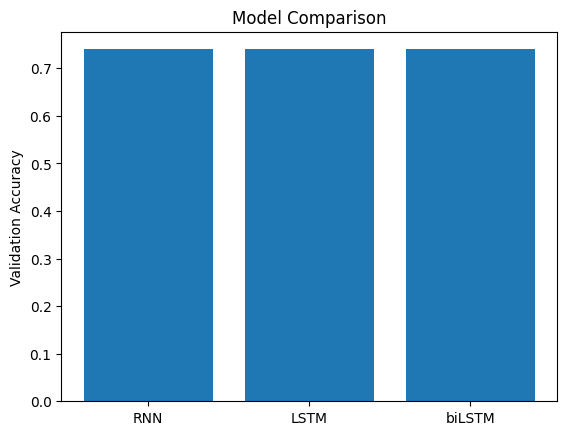

In [21]:
import matplotlib.pyplot as plt

models = list(results.keys())
acc = list(results.values())

plt.bar(models, acc)
plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")
plt.show()